In [ ]:
# Neural networks and deep learning


##  TensorFlow and Keras

* Installing TensorFlow
* Loading images

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1789016931.099477   29268 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789016931.436597   29268 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789016932.876117   29268 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
from tensorflow.keras.preprocessing.image import load_img

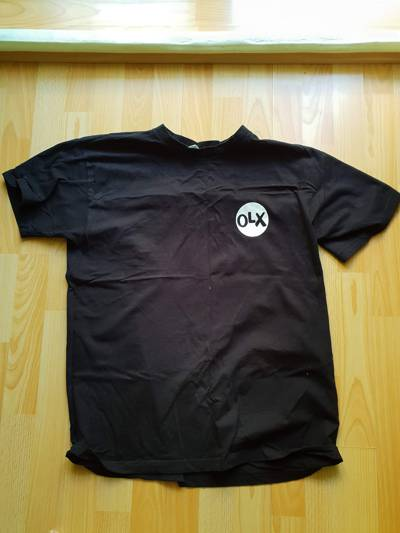

In [4]:
path = './clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [5]:
img = load_img(fullname, target_size=(299, 299))

In [6]:
x = np.array(img)
x.shape

(299, 299, 3)

## 8.3 Pre-trained convolutional neural networks

* Imagenet dataset: https://www.image-net.org/
* Pre-trained models: https://keras.io/api/applications/


In [7]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [8]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

I0000 00:00:1789016934.755609   29268 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4177 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
X = np.array([x])

In [10]:
X.shape

(1, 299, 299, 3)

In [11]:
X = preprocess_input(X)

In [12]:
# X

In [13]:
pred = model.predict(X)

I0000 00:00:1789016938.141582   29484 service.cc:153] XLA service 0x7ca1f0069580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789016938.141612   29484 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1789016938.176415   29484 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789016938.577568   29484 cuda_dnn.cc:461] Loaded cuDNN version 92501


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


I0000 00:00:1789016944.083333   29484 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [14]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.6821152)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03801858)),
  ('n04370456', 'sweatshirt', np.float32(0.0343019)),
  ('n03710637', 'maillot', np.float32(0.0113627985)),
  ('n04525038', 'velvet', np.float32(0.0018464347))]]

## 8.4 Convolutional neural networks

* Types of layers: convolutional and dense 
* Convolutional layers and filters
* Dense layers

There are more layers. Read here: https://cs231n.github.io/

## 8.5 Transfer learning

* Reading data with `ImageDataGenerator`
* Train `Xception` on smaller images (150x150)

(Better to run it with a GPU)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [17]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [18]:
X, y = next(train_ds)

In [19]:
y[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [20]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [21]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False



inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [22]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [23]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10


I0000 00:00:1789016945.081051   29268 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1789016947.867855   29482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11182__.127
E0000 00:00:1789016949.474935   29482 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789016953.474808   29482 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


79/96 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6650 - loss: 1.3148

I0000 00:00:1789016961.908399   29482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11182__.127
E0000 00:00:1789016965.878539   29482 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6763 - loss: 1.2654

E0000 00:00:1789016975.374061   29482 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


96/96 ━━━━━━━━━━━━━━━━━━━━ 35s 250ms/step - accuracy: 0.6763 - loss: 1.2654 - val_accuracy: 0.7419 - val_loss: 1.0017
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8136 - loss: 0.5743 - val_accuracy: 0.8006 - val_loss: 0.8239
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8794 - loss: 0.3433 - val_accuracy: 0.7977 - val_loss: 0.8053
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9016 - loss: 0.2859 - val_accuracy: 0.7977 - val_loss: 0.9032
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9407 - loss: 0.1773 - val_accuracy: 0.8123 - val_loss: 0.8966
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9606 - loss: 0.1122 - val_accuracy: 0.8035 - val_loss: 1.0794
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9668 - loss: 0.0929 - val_accuracy: 0.8182 - val_loss: 0.8644
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9814 - loss: 0.0612 - val_accuracy: 0.8035 - val_loss: 

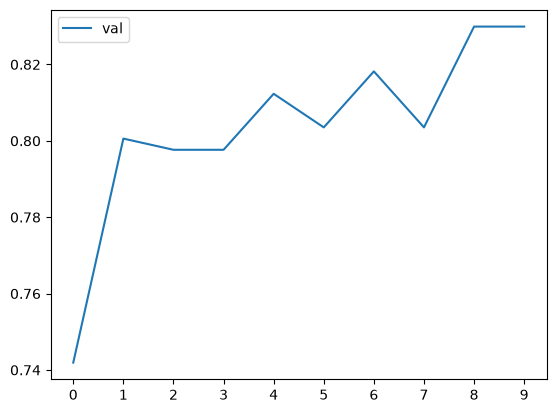

In [24]:
# plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()

## 8.6 Adjusting the learning rate

* What's the learning rate
* Trying different values

In [25]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [26]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10


I0000 00:00:1789017046.062734   29480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25171__.127


34/96 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1939 - loss: 2.3015

I0000 00:00:1789017049.287169   29481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25171__.127


96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.3455 - loss: 1.9553 - val_accuracy: 0.5103 - val_loss: 1.5782
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.5694 - loss: 1.3791 - val_accuracy: 0.6188 - val_loss: 1.2229
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6460 - loss: 1.1340 - val_accuracy: 0.6716 - val_loss: 1.0431
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6816 - loss: 0.9971 - val_accuracy: 0.7067 - val_loss: 0.9370
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7138 - loss: 0.9060 - val_accuracy: 0.7331 - val_loss: 0.8645
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7340 - loss: 0.8396 - val_accuracy: 0.7566 - val_loss: 0.8133
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7467 - loss: 0.7880 - val_accuracy: 0.7742 - val_loss: 0.7723
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7637 - loss: 0.7459 - val_accuracy: 0.7771 - val_loss: 

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.6802 - loss: 1.2007 - val_accuracy: 0.7625 - val_loss: 0.8410
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8240 - loss: 0.5608 - val_accuracy: 0.7859 - val_loss: 0.8058
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8732 - loss: 0.3783 - val_accuracy: 0.7830 - val_loss: 0.8843
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9143 - loss: 0.2369 - val_accuracy: 0.7859 - val_loss: 0.9541
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9381 - loss: 0.1820 - val_accuracy: 0.8123 - val_loss: 0.9504
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9632 - loss: 0.1176 - val_accuracy: 0.7918 - val_loss: 1.0208
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9817 - loss: 0.0745 - val_accuracy: 0.8182 - val_loss: 0.8912
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9922 - loss: 0.0363 - val_accuracy: 0.8123 - val_loss: 

I0000 00:00:1789017254.194956   29484 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67138__.127


88/96 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6332 - loss: 10.6304

I0000 00:00:1789017260.505334   29481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67138__.127


96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.6375 - loss: 10.5915 - val_accuracy: 0.7507 - val_loss: 6.7635
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7859 - loss: 5.0757 - val_accuracy: 0.7654 - val_loss: 7.4992
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8292 - loss: 3.4454 - val_accuracy: 0.7859 - val_loss: 6.5226
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8651 - loss: 2.6945 - val_accuracy: 0.7478 - val_loss: 9.7985
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8954 - loss: 2.0618 - val_accuracy: 0.7859 - val_loss: 7.4635
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9055 - loss: 1.7484 - val_accuracy: 0.7977 - val_loss: 7.3728
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9084 - loss: 1.9534 - val_accuracy: 0.7947 - val_loss: 9.2423
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9244 - loss: 1.4646 - val_accuracy: 0.7977 - val_loss:

In [27]:
del scores[0.1]
del scores[0.0001]

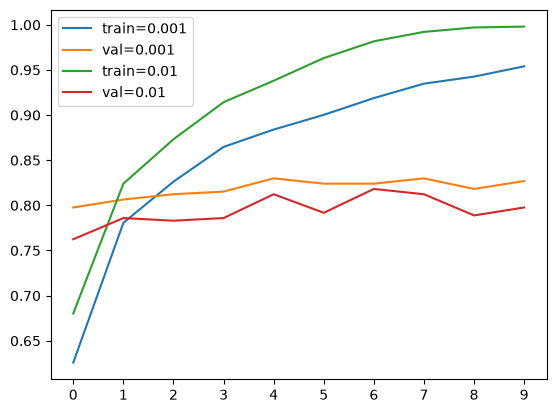

In [28]:
for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label=('train=%s' % lr))
    plt.plot(hist['val_accuracy'], label=('val=%s' % lr))

plt.xticks(np.arange(10))
plt.legend()

In [29]:
learning_rate = 0.001

## 8.7 Checkpointing

* Saving the best model only
* Training a model with callbacks

In [30]:
# model.save_weights('model_v1.h5', save_format='h5')

In [31]:
chechpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [32]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[chechpoint]
)

Epoch 1/10


I0000 00:00:1789017323.308392   29481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81127__.127


10/96 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.3219 - loss: 2.0418

I0000 00:00:1789017325.269245   29480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81127__.127


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6333 - loss: 1.0988

96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.6333 - loss: 1.0988 - val_accuracy: 0.7742 - val_loss: 0.7075
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7891 - loss: 0.6299

96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.7891 - loss: 0.6299 - val_accuracy: 0.8094 - val_loss: 0.6104
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8328 - loss: 0.5088

96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8328 - loss: 0.5088 - val_accuracy: 0.8152 - val_loss: 0.5782
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8625 - loss: 0.4273 - val_accuracy: 0.8035 - val_loss: 0.5754
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8866 - loss: 0.3775 - val_accuracy: 0.8006 - val_loss: 0.5613
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9081 - loss: 0.3250 - val_accuracy: 0.8035 - val_loss: 0.5739
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9179 - loss: 0.2901

96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9179 - loss: 0.2901 - val_accuracy: 0.8182 - val_loss: 0.5239
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9312 - loss: 0.2604 - val_accuracy: 0.8152 - val_loss: 0.5415
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9430 - loss: 0.2343

96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9430 - loss: 0.2343 - val_accuracy: 0.8328 - val_loss: 0.5261
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9482 - loss: 0.2138 - val_accuracy: 0.8182 - val_loss: 0.5350


## 8.8 Adding more layers


* Adding one inner dense layer
* Experimenting with different sizes of inner layer

In [33]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    
    outputs = keras.layers.Dense(10)(inner)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [34]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10


I0000 00:00:1789017394.073092   29480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97861__.128


 9/96 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.1806 - loss: 2.1489

I0000 00:00:1789017396.407011   29482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97861__.128


96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.4690 - loss: 1.5948 - val_accuracy: 0.6246 - val_loss: 1.1755
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6734 - loss: 0.9887 - val_accuracy: 0.7126 - val_loss: 0.8608
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7572 - loss: 0.7281 - val_accuracy: 0.7449 - val_loss: 0.7345
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8093 - loss: 0.5812 - val_accuracy: 0.7449 - val_loss: 0.7008
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8471 - loss: 0.4823 - val_accuracy: 0.7859 - val_loss: 0.6369
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8735 - loss: 0.4136 - val_accuracy: 0.7830 - val_loss: 0.6284
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8944 - loss: 0.3588 - val_accuracy: 0.7830 - val_loss: 0.6042
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9126 - loss: 0.3093 - val_accuracy: 0.7977 - val_loss: 

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.6819 - loss: 0.9549 - val_accuracy: 0.7742 - val_loss: 0.6624
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8334 - loss: 0.4874 - val_accuracy: 0.7977 - val_loss: 0.6453
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8950 - loss: 0.3321 - val_accuracy: 0.8065 - val_loss: 0.5724
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9316 - loss: 0.2273 - val_accuracy: 0.8065 - val_loss: 0.5694
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9511 - loss: 0.1713 - val_accuracy: 0.8182 - val_loss: 0.5746
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9759 - loss: 0.1109 - val_accuracy: 0.8035 - val_loss: 0.5950
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9905 - loss: 0.0736 - val_accuracy: 0.8123 - val_loss: 0.6560
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9941 - loss: 0.0569 - val_accuracy: 0.8123 - val_loss: 

I0000 00:00:1789017537.677294   29481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_126485__.128


24/96 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5716 - loss: 1.2616

I0000 00:00:1789017541.360333   29484 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_126485__.128


96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - accuracy: 0.6855 - loss: 0.9043 - val_accuracy: 0.7771 - val_loss: 0.6861
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8484 - loss: 0.4368 - val_accuracy: 0.8006 - val_loss: 0.6165
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9143 - loss: 0.2532 - val_accuracy: 0.8270 - val_loss: 0.5444
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9557 - loss: 0.1438 - val_accuracy: 0.7918 - val_loss: 0.6639
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9798 - loss: 0.0759 - val_accuracy: 0.8065 - val_loss: 0.6680
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9857 - loss: 0.0590 - val_accuracy: 0.8240 - val_loss: 0.7457
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9935 - loss: 0.0351 - val_accuracy: 0.8035 - val_loss: 0.7151
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9967 - loss: 0.0219 - val_accuracy: 0.8446 - val_loss: 

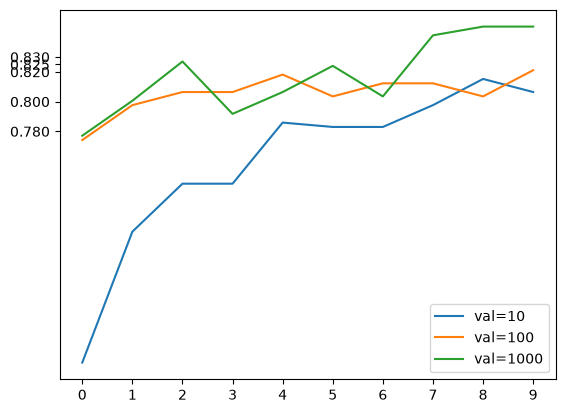

In [35]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83])
plt.legend()

## 8.9 Regularization and dropout

* Regularizing by freezing a part of the network
* Adding dropout to our model
* Experimenting with different values

In [36]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10)(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [37]:
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate,
        size_inner=size,
        droprate=droprate
    )

    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30


I0000 00:00:1789017610.575359   29480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140793__.128


92/96 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6525 - loss: 1.0470

I0000 00:00:1789017617.428171   29482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140793__.128


96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.6578 - loss: 1.0323 - val_accuracy: 0.7947 - val_loss: 0.6067
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8129 - loss: 0.5510 - val_accuracy: 0.8065 - val_loss: 0.5776
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8745 - loss: 0.3902 - val_accuracy: 0.8182 - val_loss: 0.5536
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9091 - loss: 0.2860 - val_accuracy: 0.8211 - val_loss: 0.5473
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9462 - loss: 0.2085 - val_accuracy: 0.8094 - val_loss: 0.5912
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9560 - loss: 0.1635 - val_accuracy: 0.8211 - val_loss: 0.5762
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9759 - loss: 0.1156 - val_accuracy: 0.8211 - val_loss: 0.5481
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9879 - loss: 0.0805 - val_accuracy: 0.8123 - val_loss: 

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - accuracy: 0.5502 - loss: 1.3316 - val_accuracy: 0.7801 - val_loss: 0.7579
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7128 - loss: 0.8658 - val_accuracy: 0.7947 - val_loss: 0.6489
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7546 - loss: 0.7255 - val_accuracy: 0.8065 - val_loss: 0.6107
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7842 - loss: 0.6051 - val_accuracy: 0.8182 - val_loss: 0.5686
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8129 - loss: 0.5332 - val_accuracy: 0.8240 - val_loss: 0.5454
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8334 - loss: 0.4793 - val_accuracy: 0.8123 - val_loss: 0.5897
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8527 - loss: 0.4206 - val_accuracy: 0.8270 - val_loss: 0.5243
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8615 - loss: 0.4063 - val_accuracy: 0.8211 - val_loss: 

I0000 00:00:1789018196.172695   29481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_211099__.129


67/96 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3694 - loss: 1.8832

I0000 00:00:1789018201.654882   29484 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_211099__.129


96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.4035 - loss: 1.7668 - val_accuracy: 0.5982 - val_loss: 1.1367
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.5215 - loss: 1.3802 - val_accuracy: 0.6891 - val_loss: 0.9392
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5603 - loss: 1.2656 - val_accuracy: 0.7419 - val_loss: 0.8369
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5759 - loss: 1.1829 - val_accuracy: 0.7889 - val_loss: 0.7977
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6063 - loss: 1.1122 - val_accuracy: 0.7742 - val_loss: 0.7433
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.6239 - loss: 1.0342 - val_accuracy: 0.7654 - val_loss: 0.7150
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6362 - loss: 1.0110 - val_accuracy: 0.7830 - val_loss: 0.6791
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.6428 - loss: 0.9753 - val_accuracy: 0.7742 - val_loss: 

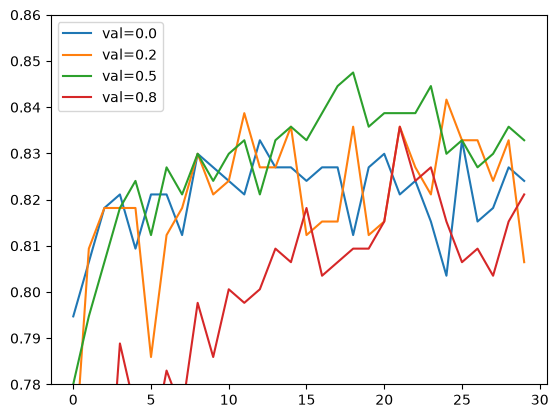

In [38]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

plt.ylim(0.78, 0.86)
plt.legend()

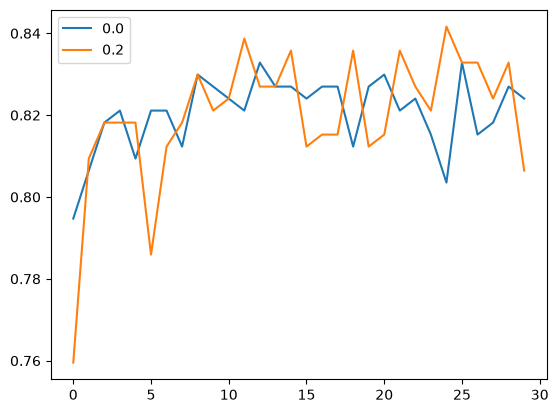

In [39]:
hist = scores[0.0]
plt.plot(hist['val_accuracy'], label=0.0)

hist = scores[0.2]
plt.plot(hist['val_accuracy'], label=0.2)

plt.legend()
#plt.plot(hist['accuracy'], label=('val=%s' % droprate))

## 8.10 Data augmentation

* Different data augmentations
* Training a model with augmentations
* How to select data augmentations?

In [40]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=10.0,
    zoom_range=0.2,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [41]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50


I0000 00:00:1789018424.767659   29481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_234535__.129


70/96 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4857 - loss: 1.5997

I0000 00:00:1789018432.943241   29483 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_234535__.129


96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.5059 - loss: 1.5336 - val_accuracy: 0.7038 - val_loss: 0.9231
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5958 - loss: 1.2077 - val_accuracy: 0.7361 - val_loss: 0.8088
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.6385 - loss: 1.0811 - val_accuracy: 0.7507 - val_loss: 0.7763
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.6460 - loss: 1.0415 - val_accuracy: 0.7214 - val_loss: 0.7693
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.6532 - loss: 1.0165 - val_accuracy: 0.7537 - val_loss: 0.7753
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.6760 - loss: 0.9446 - val_accuracy: 0.7419 - val_loss: 0.7567
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.6760 - loss: 0.9483 - val_accuracy: 0.7595 - val_loss: 0.7381
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.6946 - loss: 0.9057 - val_accuracy: 0.7390 - val_loss

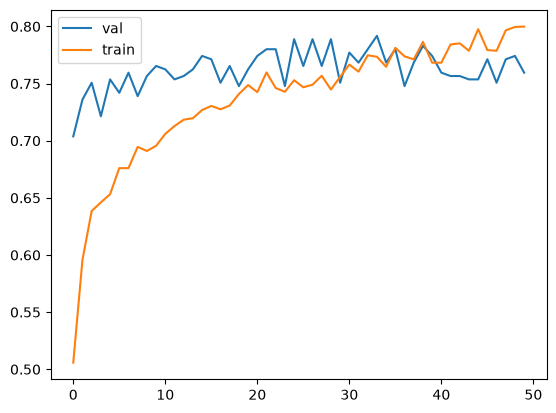

In [42]:
hist = history.history
plt.plot(hist['val_accuracy'], label='val')
plt.plot(hist['accuracy'], label='train')

plt.legend()

## 8.11 Training a larger model

* Train a 299x299 model

In [43]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10)(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [44]:
input_size = 299

In [45]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(input_size, input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [46]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [47]:
learning_rate = 0.01
size = 100
droprate = 0.5

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=30, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/30


I0000 00:00:1789018889.898136   29483 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_267011__.129
W0000 00:00:1789018903.509178   29483 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.64GiB (rounded to 2832409344)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1789018903.513417   29483 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1789018903.513422   29483 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 309, Chunks in use: 309. 77.2KiB allocated for chunks. 77.2KiB in use in bin. 25.0KiB client-requested in use in bin.
I0000 00:00:1789018903.513427   29483 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 203, Chunks in use: 203. 105.2KiB allocated for chunks. 105.2KiB in use in bin. 99.0KiB client-requested in use in

80/96 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step - accuracy: 0.6180 - loss: 1.1370

I0000 00:00:1789018938.423519   29483 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_267011__.129
W0000 00:00:1789018949.644031   29483 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.31GiB (rounded to 2478367488)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1789018949.644239   29483 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1789018949.644243   29483 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 316, Chunks in use: 316. 79.0KiB allocated for chunks. 79.0KiB in use in bin. 25.1KiB client-requested in use in bin.
I0000 00:00:1789018949.644250   29483 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 205, Chunks in use: 204. 106.2KiB allocated for chunks. 105.8KiB in use in bin. 99.4KiB client-requested in use in

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.6333 - loss: 1.0813

W0000 00:00:1789018983.740904   29482 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.73GiB (rounded to 1858794240)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1789018983.741031   29482 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1789018983.741035   29482 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 321, Chunks in use: 321. 80.2KiB allocated for chunks. 80.2KiB in use in bin. 25.1KiB client-requested in use in bin.
I0000 00:00:1789018983.741041   29482 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 205, Chunks in use: 204. 106.2KiB allocated for chunks. 105.8KiB in use in bin. 99.4KiB client-requested in use in bin.
I0000 00:00:1789018983.741045   29482 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 183, Chunks in use: 182. 204.0KiB 

96/96 ━━━━━━━━━━━━━━━━━━━━ 108s 810ms/step - accuracy: 0.6333 - loss: 1.0813 - val_accuracy: 0.8240 - val_loss: 0.5385
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 280ms/step - accuracy: 0.7194 - loss: 0.7764 - val_accuracy: 0.7947 - val_loss: 0.5191
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 275ms/step - accuracy: 0.7275 - loss: 0.7413 - val_accuracy: 0.7977 - val_loss: 0.5387
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 285ms/step - accuracy: 0.7396 - loss: 0.7123 - val_accuracy: 0.8240 - val_loss: 0.4975
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 280ms/step - accuracy: 0.7676 - loss: 0.6379 - val_accuracy: 0.8094 - val_loss: 0.5108
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.7640 - loss: 0.6526

96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 289ms/step - accuracy: 0.7640 - loss: 0.6526 - val_accuracy: 0.8504 - val_loss: 0.4163
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.7604 - loss: 0.6269 - val_accuracy: 0.8387 - val_loss: 0.4637
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7617 - loss: 0.6255

96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 297ms/step - accuracy: 0.7617 - loss: 0.6255 - val_accuracy: 0.8680 - val_loss: 0.4437
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 294ms/step - accuracy: 0.7982 - loss: 0.5570 - val_accuracy: 0.8592 - val_loss: 0.4384
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 264ms/step - accuracy: 0.7927 - loss: 0.5991 - val_accuracy: 0.8446 - val_loss: 0.4625
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 307ms/step - accuracy: 0.7852 - loss: 0.5957 - val_accuracy: 0.8622 - val_loss: 0.4429
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 277ms/step - accuracy: 0.8054 - loss: 0.5307 - val_accuracy: 0.8504 - val_loss: 0.4430
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 273ms/step - accuracy: 0.8051 - loss: 0.5494 - val_accuracy: 0.8622 - val_loss: 0.4196
Epoch 14/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 289ms/step - accuracy: 0.7930 - loss: 0.5603 - val_accuracy: 0.8622 - val_loss: 0.4321
Epoch 15/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.8044 - loss: 0.5317 - val_accuracy:

96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 278ms/step - accuracy: 0.8119 - loss: 0.4816 - val_accuracy: 0.8768 - val_loss: 0.4535
Epoch 23/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.8266 - loss: 0.4800 - val_accuracy: 0.8592 - val_loss: 0.4495
Epoch 24/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 277ms/step - accuracy: 0.8240 - loss: 0.4747 - val_accuracy: 0.8387 - val_loss: 0.5550
Epoch 25/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 271ms/step - accuracy: 0.8364 - loss: 0.4665 - val_accuracy: 0.8710 - val_loss: 0.4473
Epoch 26/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 281ms/step - accuracy: 0.8370 - loss: 0.4345 - val_accuracy: 0.8622 - val_loss: 0.4255
Epoch 27/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 295ms/step - accuracy: 0.8380 - loss: 0.4251 - val_accuracy: 0.8651 - val_loss: 0.4114
Epoch 28/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 263ms/step - accuracy: 0.8321 - loss: 0.4665 - val_accuracy: 0.8475 - val_loss: 0.5133
Epoch 29/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 294ms/step - accuracy: 0.8224 - loss: 0.4662 - val_accuracy

## 8.12 Using the model

* Loading the model
* Evaluating the model
* Getting predictions

In [48]:
import tensorflow as tf
from tensorflow import keras

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.applications.xception import preprocess_input

In [50]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './clothing-dataset-small/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)

Found 372 images belonging to 10 classes.


In [52]:
model = keras.models.load_model('xception_v4_1_22_0.877.h5')

In [53]:
model.evaluate(test_ds)

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8864 - loss: 0.4016

W0000 00:00:1789020130.745659   29481 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.65GiB (rounded to 1770283776)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1789020130.746549   29481 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1789020130.746563   29481 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 352, Chunks in use: 350. 88.0KiB allocated for chunks. 87.5KiB in use in bin. 26.8KiB client-requested in use in bin.
I0000 00:00:1789020130.746574   29481 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 217, Chunks in use: 217. 113.0KiB allocated for chunks. 113.0KiB in use in bin. 105.8KiB client-requested in use in bin.
I0000 00:00:1789020130.746581   29481 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 194, Chunks in use: 194. 216.8KiB

12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.8898 - loss: 0.3874 


[0.3874068856239319, 0.8897849321365356]

In [54]:
path = 'clothing-dataset-small/test/pants/c8d21106-bbdb-4e8d-83e4-bf3d14e54c16.jpg'

In [55]:
img = load_img(path, target_size=(299, 299))

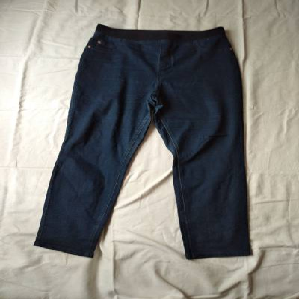

In [56]:
img

In [57]:
import numpy as np

In [58]:
x = np.array(img)
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [59]:
X = preprocess_input(X)

In [60]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [61]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [62]:
dict(zip(classes, pred[0]))

{'dress': np.float32(-15.964052),
 'hat': np.float32(-32.65262),
 'longsleeve': np.float32(-17.936821),
 'outwear': np.float32(-15.993437),
 'pants': np.float32(22.126778),
 'shirt': np.float32(-24.873783),
 'shoes': np.float32(-18.00778),
 'shorts': np.float32(11.597472),
 'skirt': np.float32(-11.661859),
 't-shirt': np.float32(-10.566193)}

## 8.13 Summary

* We can use pre-trained models for general image classification
* Convolutional layers let us turn an image into a vector
* Dense layers use the vector to make the predictions
* Instead of training a model from scratch, we can use transfer learning and re-use already trained convolutional layers
* First, train a small model (150x150) before training a big one (299x299)
* Learning rate - how fast the model trians. Fast learners aren't always best ones
* We can save the best model using callbacks and checkpointing
* To avoid overfitting, use dropout and augmentation


* Add more data, e.g. more images and classes
* Albumentations - another way of generating augmentations
* Use PyTorch or MXNet instead of TensorFlow/Keras
* In addition to Xception, there are others architectures - try them 

Other projects:

* cats vs dogs
* Hotdog vs not hotdog
* Category of images

